# Main vs Band Power MLP

Classical spectral band power (90 features) + MLP vs GC-CNN under identical LOPO.

In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, CANONICAL_CHANNELS, N_CHANNELS, FS,
    WINDOW_SEC, STEP_SEC, PREICTAL_SEC, SPH_SEC,
    POSTICTAL_EXCL_SEC, EXCLUDED_PATIENTS, RANDOM_SEED, RESULTS_DIR
)
from summary_parser import parse_all_summaries
from data_loader    import load_edf
from preprocessing  import bandpass_filter, segment_signal, label_windows
from metrics        import evaluate_predictions
np.random.seed(RANDOM_SEED)
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from metrics import find_optimal_threshold
torch.manual_seed(RANDOM_SEED)
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BANDS   = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'broadband':(0.5,30)}
N_FEAT  = N_CHANNELS * len(BANDS)
print(f'Device: {DEVICE}  Features: {N_FEAT}')

Device: cpu  Features: 90


In [2]:
# Cell 1 — Parse
all_seizures = parse_all_summaries(DATA_ROOT)
print(f'Parsed {len(all_seizures)} patient entries.')

[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] chb12: 13 seizure-containing files, 40 total seizures
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total

In [3]:
# Cell 2 — Band power extraction
def band_power_features(window, fs, bands):
    freqs, psd = welch(window, fs=fs, nperseg=min(256, window.shape[1]))
    features = []
    for lo, hi in bands.values():
        mask = (freqs >= lo) & (freqs <= hi)
        band_pow = np.trapz(psd[:, mask], freqs[mask], axis=1)
        features.append(np.log1p(band_pow))
    feat = np.concatenate(features)
    feat = (feat - feat.mean()) / (feat.std() + 1e-8)
    return feat.astype(np.float32)

bp_patient_data = {}
patients = sorted([p for p in os.listdir(DATA_ROOT)
                   if os.path.isdir(os.path.join(DATA_ROOT, p))
                   and p.startswith('chb') and p not in EXCLUDED_PATIENTS])

for patient_id in patients:
    file_seizure_map = all_seizures.get(patient_id, {})
    if not file_seizure_map:
        continue
    print(f'\n{"─"*55}\nPatient: {patient_id}')
    all_X, all_y = [], []
    for filename in sorted(file_seizure_map):
        seizures = file_seizure_map[filename]
        if not seizures:
            continue
        edf_path = os.path.join(DATA_ROOT, patient_id, filename)
        if not os.path.exists(edf_path):
            continue
        try:
            signal, fs = load_edf(edf_path)
        except Exception:
            continue
        filtered  = bandpass_filter(signal)
        windows   = segment_signal(filtered)
        n_samples = filtered.shape[1]
        labels    = label_windows(n_samples, seizures)
        valid     = labels != -1
        windows   = windows[valid]
        labels    = labels[valid]
        if (labels == 1).sum() == 0:
            continue
        feats = np.stack([band_power_features(w, fs, BANDS) for w in windows])
        all_X.append(feats); all_y.append(labels)
        print(f'  [OK] {filename}  pre={(labels==1).sum()}  int={(labels==0).sum()}')
    if not all_X:
        continue
    X = np.concatenate(all_X); y = np.concatenate(all_y)
    bp_patient_data[patient_id] = {'X': X, 'y': y}
    print(f'  Total: {len(y)} windows')

patient_ids = sorted(bp_patient_data.keys())
print(f'\nBand power data ready. Patients: {len(bp_patient_data)}')


───────────────────────────────────────────────────────
Patient: chb01
  [OK] chb01_03.edf  pre=148  int=146
    [LABEL] Seizure at 1467s: preictal window out of bounds (would start at -333s) — skipping preictal label.
    [LABEL] Seizure at 1732s: preictal window out of bounds (would start at -68s) — skipping preictal label.
    [LABEL] Seizure at 1015s: preictal window out of bounds (would start at -785s) — skipping preictal label.
    [LABEL] Seizure at 1720s: preictal window out of bounds (would start at -80s) — skipping preictal label.
    [LABEL] Seizure at 327s: preictal window out of bounds (would start at -1473s) — skipping preictal label.
  [OK] chb01_26.edf  pre=148  int=33
  Total: 475 windows

───────────────────────────────────────────────────────
Patient: chb02
  [OK] chb02_16+.edf  pre=148  int=144
    [LABEL] Seizure at 130s: preictal window out of bounds (would start at -1670s) — skipping preictal label.
  [OK] chb02_19.edf  pre=148  int=183
  Total: 623 windows

───

In [4]:
# Cell 3 — MLP model
class BPDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class BandPowerMLP(nn.Module):
    def __init__(self, n_feat=90, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_feat,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256,128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128,64),     nn.ReLU(),
            nn.Linear(64,1),       nn.Sigmoid()
        )
    def forward(self, x): return self.net(x).squeeze(1)

m = BandPowerMLP(N_FEAT).to(DEVICE)
print(f'Params: {sum(p.numel() for p in m.parameters() if p.requires_grad):,}')
del m

Params: 65,281


In [5]:
# Cell 4 — Training utilities
MAX_EPOCHS = 50; PATIENCE = 10; BATCH_SIZE = 64; LR = 1e-3; VAL_FRAC = 0.15

def train_bp(X_tr, y_tr, X_va, y_va):
    n_pos = max(int((y_tr==1).sum()), 1); n_neg = max(int((y_tr==0).sum()), 1)
    pw    = torch.tensor([min(n_neg/n_pos, 50.0)], dtype=torch.float32).to(DEVICE)
    model = BandPowerMLP(N_FEAT).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    tr_dl = DataLoader(BPDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
    va_dl = DataLoader(BPDataset(X_va, y_va), batch_size=BATCH_SIZE)
    best_val, best_wts, p_ctr = float('inf'), None, 0
    for epoch in range(1, MAX_EPOCHS+1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            p = model(xb)
            w = torch.where(yb==1, pw.expand_as(yb), torch.ones_like(yb))
            loss = (w * nn.functional.binary_cross_entropy(p, yb, reduction='none')).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval(); va_loss = 0.0
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                p = model(xb)
                w = torch.where(yb==1, pw.expand_as(yb), torch.ones_like(yb))
                va_loss += (w * nn.functional.binary_cross_entropy(p, yb, reduction='none')).mean().item() * len(yb)
        va_loss /= len(va_dl.dataset)
        if epoch % 5 == 0: print(f'  Epoch {epoch}/{MAX_EPOCHS}  val={va_loss:.4f}')
        if va_loss < best_val:
            best_val = va_loss; best_wts = {k: v.cpu().clone() for k,v in model.state_dict().items()}; p_ctr = 0
        else:
            p_ctr += 1
            if p_ctr >= PATIENCE: print(f'  Early stop @ {epoch}'); break
    model.load_state_dict(best_wts)
    return model

def predict_bp(model, X):
    model.eval()
    dl = DataLoader(BPDataset(X, np.zeros(len(X))), batch_size=BATCH_SIZE)
    out = []
    with torch.no_grad():
        for xb, _ in dl: out.append(model(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

print('Training utilities ready.')

Training utilities ready.


In [6]:
# Cell 5 — LOPO
bp_lopo_results = {}
n_folds = len(patient_ids)
print('='*60)
print(f'Band Power MLP LOPO  ({n_folds} folds) | device: {DEVICE}')
print('='*60)

for fold_idx, test_pid in enumerate(patient_ids, 1):
    print(f'\n[Fold {fold_idx}/{n_folds}]  Test: {test_pid}')
    X_pool = np.concatenate([bp_patient_data[p]['X'] for p in patient_ids if p != test_pid])
    y_pool = np.concatenate([bp_patient_data[p]['y'] for p in patient_ids if p != test_pid])
    tr_idx, va_idx = train_test_split(np.arange(len(y_pool)), test_size=VAL_FRAC,
                                       random_state=RANDOM_SEED, stratify=y_pool)
    model  = train_bp(X_pool[tr_idx], y_pool[tr_idx], X_pool[va_idx], y_pool[va_idx])
    scores = predict_bp(model, bp_patient_data[test_pid]['X'])
    y_test = bp_patient_data[test_pid]['y']
    metrics = evaluate_predictions(y_test, scores, threshold=0.5, patient_id=test_pid)
    bp_lopo_results[test_pid] = metrics
    print(f'  AUC={metrics["auc"]:.3f}  Sens={metrics["sensitivity"]:.3f}  '
          f'Spec={metrics["specificity"]:.3f}  FPR/h={metrics["fpr_per_hour"]:.1f}')

print('\nBand Power LOPO complete.')

Band Power MLP LOPO  (21 folds) | device: cpu

[Fold 1/21]  Test: chb01
  Epoch 5/50  val=0.7657
  Epoch 10/50  val=0.7395
  Epoch 15/50  val=0.7070
  Epoch 20/50  val=0.6947
  Epoch 25/50  val=0.6839
  Epoch 30/50  val=0.6722
  Epoch 35/50  val=0.6653
  Epoch 40/50  val=0.6541
  Epoch 45/50  val=0.6584
  Epoch 50/50  val=0.6451
  AUC=0.509  Sens=0.710  Spec=0.207  FPR/h=285.6

[Fold 2/21]  Test: chb02
  Epoch 5/50  val=0.7561
  Epoch 10/50  val=0.7325
  Epoch 15/50  val=0.7083
  Epoch 20/50  val=0.6972
  Epoch 25/50  val=0.6798
  Epoch 30/50  val=0.6807
  Epoch 35/50  val=0.6641
  Epoch 40/50  val=0.6477
  Epoch 45/50  val=0.6467
  Epoch 50/50  val=0.6452
  AUC=0.429  Sens=0.382  Spec=0.480  FPR/h=187.2

[Fold 3/21]  Test: chb03
  Epoch 5/50  val=0.7612
  Epoch 10/50  val=0.7290
  Epoch 15/50  val=0.7165
  Epoch 20/50  val=0.6973
  Epoch 25/50  val=0.6829
  Epoch 30/50  val=0.6749
  Epoch 35/50  val=0.6629
  Epoch 40/50  val=0.6559
  Epoch 45/50  val=0.6445
  Epoch 50/50  val=0.6463
 

=== Band Power MLP LOPO ===
patient   auc  auc_pr  sensitivity  specificity    f1  balanced_accuracy  fpr_per_hour
  chb01 0.509   0.655        0.710        0.207 0.648              0.458       285.587
  chb02 0.429   0.454        0.382        0.480 0.390              0.431       187.156
  chb03 0.511   0.692        0.658        0.294 0.658              0.476       254.019
  chb04 0.441   0.152        0.443        0.490 0.201              0.467       183.452
  chb05 0.585   0.717        0.306        0.809 0.433              0.557        68.845
  chb06 0.474   0.154        0.858        0.171 0.277              0.514       298.540
  chb07 0.538   0.157        0.852        0.164 0.261              0.508       300.820
  chb08 0.523   0.586        0.648        0.428 0.629              0.538       205.906
  chb09 0.425   0.169        0.779        0.217 0.329              0.498       281.739
  chb10 0.595   0.308        0.448        0.668 0.374              0.558       119.668
  chb13 0.428  

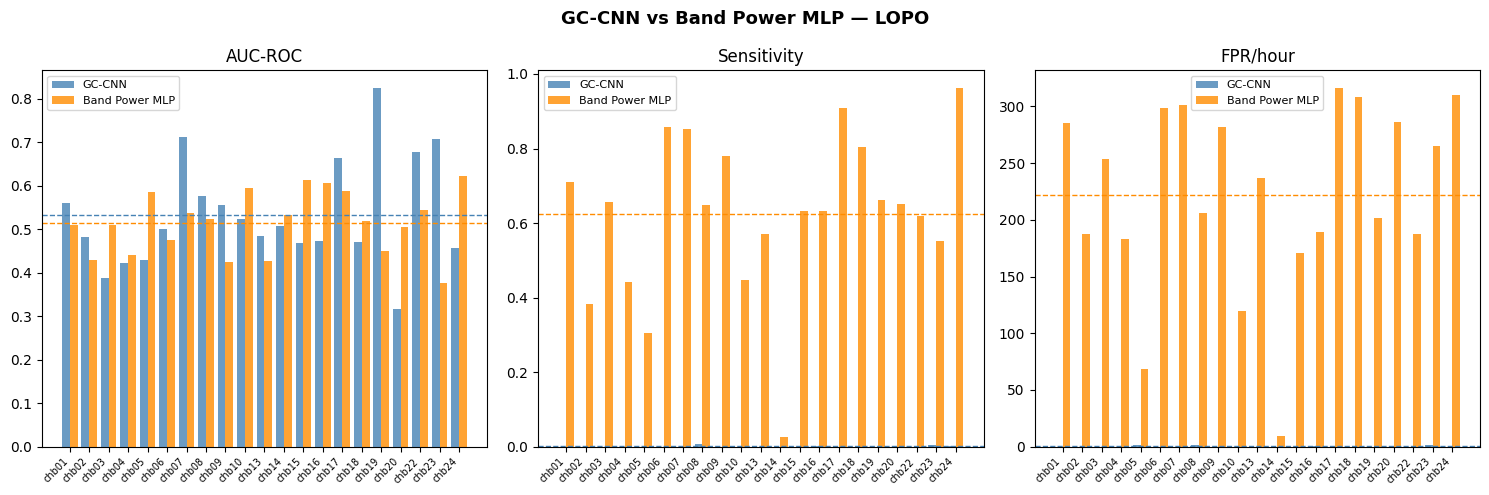

Done.


In [7]:
# Cell 6 — Save & plot
METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity', 'f1', 'balanced_accuracy', 'fpr_per_hour']

rows = [{'patient': pid, **{k: bp_lopo_results[pid][k] for k in METRIC_KEYS}} for pid in patient_ids]
bp_df = pd.DataFrame(rows)
bp_df = pd.concat([bp_df,
    pd.DataFrame([{'patient':'MEAN', **{k: round(bp_df[k].mean(),4) for k in METRIC_KEYS}}]),
    pd.DataFrame([{'patient':'STD',  **{k: round(bp_df[k].std(), 4) for k in METRIC_KEYS}}])
], ignore_index=True)
print('=== Band Power MLP LOPO ===')
print(bp_df.to_string(index=False, float_format='{:.3f}'.format))
os.makedirs(RESULTS_DIR, exist_ok=True)
bp_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_band_power.csv'), index=False)

gc_csv = os.path.join(RESULTS_DIR, 'lopo_results.csv')
if os.path.exists(gc_csv):
    gc_df  = pd.read_csv(gc_csv)
    pid_col = [c for c in gc_df.columns if 'patient' in c.lower()][0]
    gc_df   = gc_df.rename(columns={pid_col:'patient'})
    gc_df   = gc_df[~gc_df['patient'].isin(['MEAN','STD'])].reset_index(drop=True)
    bp_df2  = bp_df[~bp_df['patient'].isin(['MEAN','STD'])].reset_index(drop=True)
    auc_col = 'auc' if 'auc' in gc_df.columns else gc_df.columns[1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, metric, title in zip(axes, [auc_col,'sensitivity','fpr_per_hour'],
                                        ['AUC-ROC','Sensitivity','FPR/hour']):
        x = np.arange(len(patient_ids))
        gc_v  = gc_df[metric].values  if metric in gc_df.columns  else np.zeros(len(patient_ids))
        bp_v  = bp_df2['auc'].values  if metric == auc_col else bp_df2[metric].values
        ax.bar(x-0.2, gc_v, 0.4, label='GC-CNN', color='steelblue', alpha=0.8)
        ax.bar(x+0.2, bp_v, 0.4, label='Band Power MLP', color='darkorange', alpha=0.8)
        ax.axhline(gc_v.mean(), color='steelblue', linestyle='--', lw=1)
        ax.axhline(bp_v.mean(), color='darkorange', linestyle='--', lw=1)
        ax.set_xticks(x); ax.set_xticklabels(patient_ids, rotation=45, ha='right', fontsize=7)
        ax.set_title(title); ax.legend(fontsize=8)
    plt.suptitle('GC-CNN vs Band Power MLP — LOPO', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,'comparison_gc_vs_bandpower.png'), dpi=150, bbox_inches='tight')
    plt.show()
print('Done.')